# Training Video classification Models

In [74]:
import torch
from transformers import VideoMAEModel, VideoMAEImageProcessor

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")
model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")

model = model.to(device)
model.eval()

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 2045.61it/s, Materializing param=layernorm.weight]                                 
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decode

VideoMAEModel(
  (embeddings): VideoMAEEmbeddings(
    (patch_embeddings): VideoMAEPatchEmbeddings(
      (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
    )
  )
  (encoder): VideoMAEEncoder(
    (layer): ModuleList(
      (0-11): 12 x VideoMAELayer(
        (attention): VideoMAEAttention(
          (attention): VideoMAESelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=False)
            (key): Linear(in_features=768, out_features=768, bias=False)
            (value): Linear(in_features=768, out_features=768, bias=False)
          )
          (output): VideoMAESelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): VideoMAEIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): VideoMAEOutput

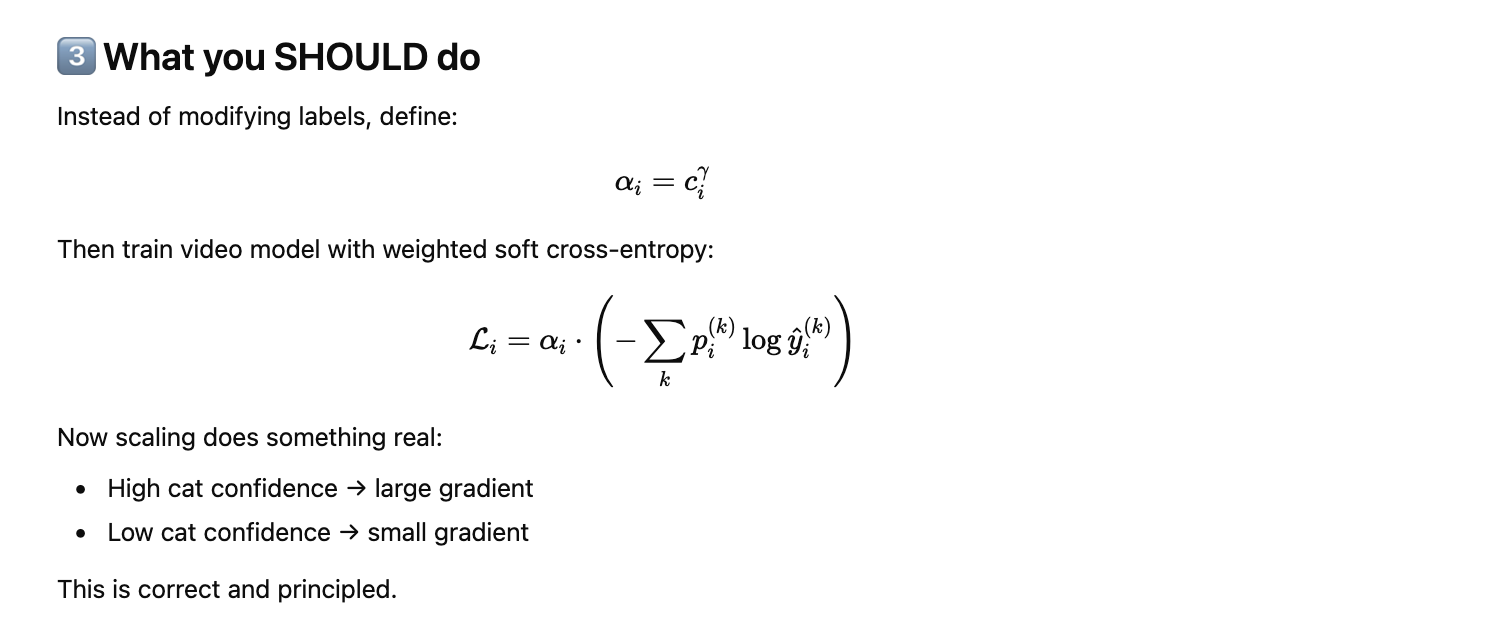

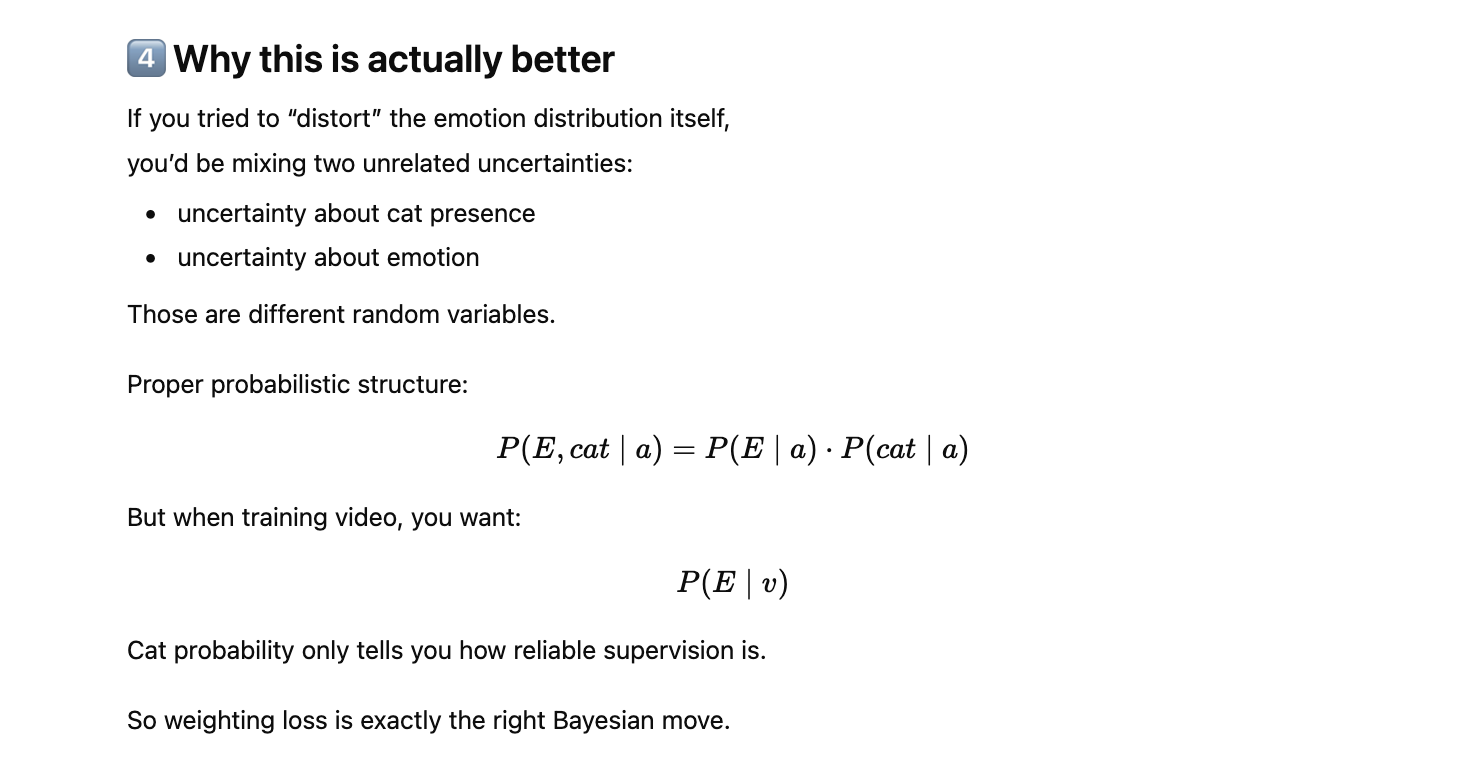

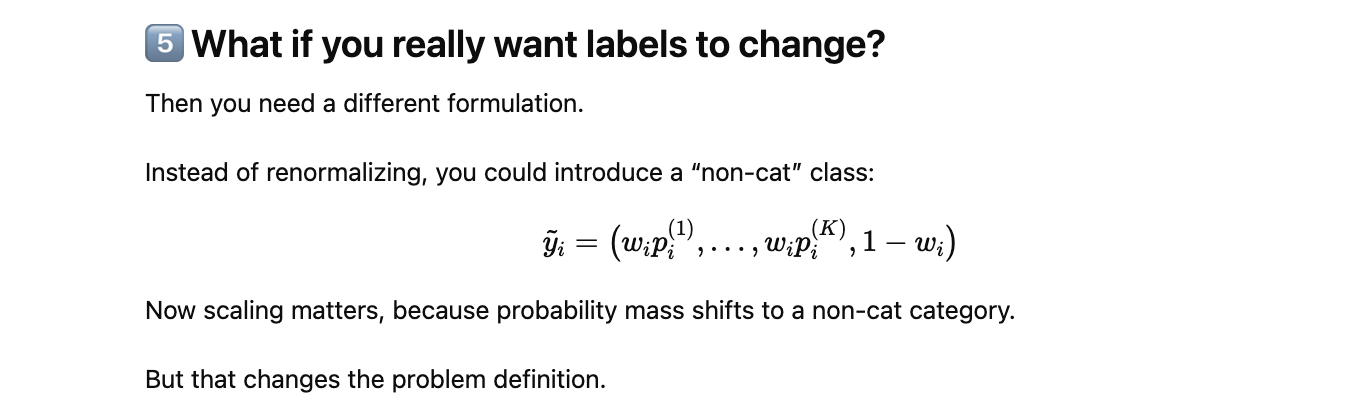

The teacher is less certain.

But that is expected.
The real danger would be:
High-confidence wrong predictions.
You are instead seeing:
Lower confidence overall.
That is actually safer.


Model is extremely confident on its native domain.

This suggests:
The model is calibrated for its own domain but under-confident on shifted data.
That is textbook domain shift.


Because of domain shift:
You may want to use class-balanced weighting when training video.

## Extracting Video Embeddings

In [40]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import VideoMAEModel, VideoMAEImageProcessor
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
from tqdm import tqdm

In [3]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

NUM_CLASSES = 10
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-4
GAMMA = 2.0

Device: mps


In [4]:
def load_metadata(metadata_path):
    samples = []

    with open(metadata_path, "r") as f:
        for line in f:
            entry = json.loads(line)
            original = entry["original_video"]

            for snip in entry["snippets"]:
                samples.append({
                    "snippet_id": snip["id"],
                    "original_video": original,
                    "cat_proba": snip["audio_proba"]
                })

    return samples

In [5]:
metadata = load_metadata("metadata.jsonl")
metadata[0]

{'snippet_id': 'SPAPelotas - gatinhos mamando._snip_1',
 'original_video': 'SPAPelotas - gatinhos mamando..mp4',
 'cat_proba': 0.6237}

In [6]:
def group_split(samples, test_size=0.2):
    groups = [s["original_video"] for s in samples]
    indices = np.arange(len(samples))

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    train_idx, val_idx = next(splitter.split(indices, groups=groups))

    train_samples = [samples[i] for i in train_idx]
    val_samples = [samples[i] for i in val_idx]

    return train_samples, val_samples

In [7]:
train_sample, test_samples = group_split(metadata, test_size=0.2)
len(train_sample), len(test_samples)

(1876, 482)

In [8]:
processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base")
videomae = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base").to(DEVICE)
videomae.eval()

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 1414.05it/s, Materializing param=layernorm.weight]                                 
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decode

VideoMAEModel(
  (embeddings): VideoMAEEmbeddings(
    (patch_embeddings): VideoMAEPatchEmbeddings(
      (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
    )
  )
  (encoder): VideoMAEEncoder(
    (layer): ModuleList(
      (0-11): 12 x VideoMAELayer(
        (attention): VideoMAEAttention(
          (attention): VideoMAESelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=False)
            (key): Linear(in_features=768, out_features=768, bias=False)
            (value): Linear(in_features=768, out_features=768, bias=False)
          )
          (output): VideoMAESelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): VideoMAEIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): VideoMAEOutput

In [9]:
@torch.no_grad()
def extract_embedding(video_frames):
    inputs = processor(video_frames, return_tensors="pt").to(DEVICE)
    outputs = videomae(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0]  # CLS token
    return cls_embedding.squeeze(0)

### Getting audio Labels

In [10]:
idx_to_class = {
    0: 'Angry',
    1: 'Defence',
    2: 'Fighting',
    3: 'Happy',
    4: 'HuntingMind',
    5: 'Mating',
    6: 'MotherCall',
    7: 'Paining',
    8: 'Resting',
    9: 'Warning'
}

In [11]:
class_to_idx = {
    'Angry': 0,
    'Defence': 1,
    'Fighting': 2,
    'Happy': 3,
    'HuntingMind': 4,
    'Mating': 5,
    'MotherCall': 6,
    'Paining': 7,
    'Resting': 8,
    'Warning': 9
}

In [12]:
# Example structure:
# audio_labels[snippet_id] = {
#     "emotion": int,
#     "emotion_confidence": float,
#     "cat_proba": float
# }
audio_labels = {}

In [13]:
from audio_classifier_utils.dataset import CatEmotionInferenceDataset
from audio_classifier_utils.audio_config import AudioConfig
from audio_classifier_utils.models.cnn14 import CatEmotionModel

audio_config = AudioConfig()
cnn14_model = CatEmotionModel(audio_config).to(DEVICE)
cnn14_model.load_state_dict(torch.load("checkpoints/best_model_final.pth")['model_state_dict'])
cnn14_model.eval()

Loading pre-trained weights from audio_classifier_utils/pretrained_weights/Cnn14_16k_mAP=0.438.pth...
Weights loaded successfully!


CatEmotionModel(
  (backbone): Cnn14(
    (spectrogram_extractor): Spectrogram(
      (stft): STFT(
        (conv_real): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
        (conv_imag): Conv1d(1, 513, kernel_size=(1024,), stride=(320,), bias=False)
      )
    )
    (logmel_extractor): LogmelFilterBank()
    (spec_augmenter): SpecAugmentation(
      (time_dropper): DropStripes()
      (freq_dropper): DropStripes()
    )
    (bn0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv_block1): ConvBlock(
      (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (conv_block2): ConvBlock(
      (conv1): Conv2d(64, 128

In [14]:
metadata[0]

{'snippet_id': 'SPAPelotas - gatinhos mamando._snip_1',
 'original_video': 'SPAPelotas - gatinhos mamando..mp4',
 'cat_proba': 0.6237}

In [23]:
audio_files = [f"dataset_snippets/{f['snippet_id']}.mp3" for f in metadata]

In [24]:
audio_dataset = CatEmotionInferenceDataset(
    file_list=audio_files, 
    metadata_path="metadata.jsonl",
    config=audio_config
)
audio_loader = DataLoader(
    audio_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

In [29]:
from tqdm import tqdm

audio_labels = {}
cnn14_model.eval()

with torch.no_grad():
    for batch in tqdm(audio_loader, desc="Generating audio pseudo-labels"):

        inputs = batch["audio"].to(DEVICE)
        snippet_ids = batch["snippet_id"]
        cat_probas = batch["cat_proba"]

        logits = cnn14_model(inputs)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        for i in range(len(snippet_ids)):
            audio_labels[snippet_ids[i]] = {
                "emotion": preds[i].item(),
                "probs": probs[i].cpu().tolist(),
                "cat_proba": float(cat_probas[i])
            }

Generating audio pseudo-labels: 100%|██████████| 148/148 [00:28<00:00,  5.16it/s]


In [30]:
import json

with open("audio_labels.json", "w") as f:
    json.dump(audio_labels, f)

In [36]:
audio_labels['SPAPelotas - gatinhos mamando._snip_1']

{'emotion': 6,
 'probs': [1.2436222277756315e-05,
  2.3187158859627743e-08,
  0.0007640420808456838,
  0.04736505076289177,
  0.005032757297158241,
  0.0003127463278360665,
  0.8623177409172058,
  0.08419403433799744,
  5.317932050274976e-07,
  5.279411539049761e-07],
 'cat_proba': 0.6237}

In [38]:
idx_to_class[audio_labels['SPAPelotas - gatinhos mamando._snip_1']["emotion"]]

'MotherCall'

### Video Embeddings

In [56]:
import cv2
import numpy as np
from PIL import Image

In [42]:
model.config.num_frames

16

In [64]:
def sample_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        raise ValueError("Empty video")

    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    frames = np.stack(frames)

    # frames: output from sample_frames
    pil_frames = [Image.fromarray(f) for f in frames]  # shape (H, W, 3), dtype uint8

    return frames  # shape: (16, H, W, 3)

In [79]:
num_frames = 16

# 1. Sample frames (returns numpy array HWC uint8)
frames = sample_frames(
    "dataset_snippets/SPAPelotas - gatinhos mamando._snip_1.mp4",
    num_frames=num_frames
)

# 2. Pad if needed
if len(frames) < num_frames:
    pad_count = num_frames - len(frames)
    frames = np.concatenate(
        [frames, np.repeat(frames[-1][np.newaxis, ...], pad_count, axis=0)],
        axis=0
    )

# 3. Use processor directly
inputs = processor(
    list(frames),          # list of HWC images
    return_tensors="pt"
)

# Processor returns (num_frames, 3, 224, 224)
video_tensor = inputs["pixel_values"]

# 4. Add batch dimension → (1, num_frames, 3, 224, 224)
# video_tensor = video_tensor.unsqueeze(0)
video_tensor = video_tensor.to(DEVICE)

# 5. Forward pass
with torch.no_grad():
    outputs = model(pixel_values=video_tensor)

embedding = outputs.last_hidden_state[:, 0]
print("Embedding shape:", embedding.shape)

Embedding shape: torch.Size([1, 768])


In [80]:
def extract_embedding(video_path, num_frames=16):
    frames = sample_frames(video_path, num_frames=num_frames)

    if len(frames) < num_frames:
        pad_count = num_frames - len(frames)
        frames = np.concatenate(
            [frames, np.repeat(frames[-1][np.newaxis, ...], pad_count, axis=0)],
            axis=0
        )

    inputs = processor(
        list(frames),
        return_tensors="pt"
    )

    video_tensor = inputs["pixel_values"].to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values=video_tensor)

    embedding = outputs.last_hidden_state[:, 0]
    return embedding.squeeze(0)

In [81]:
extract_embedding("dataset_snippets/SPAPelotas - gatinhos mamando._snip_1.mp4").shape

torch.Size([768])

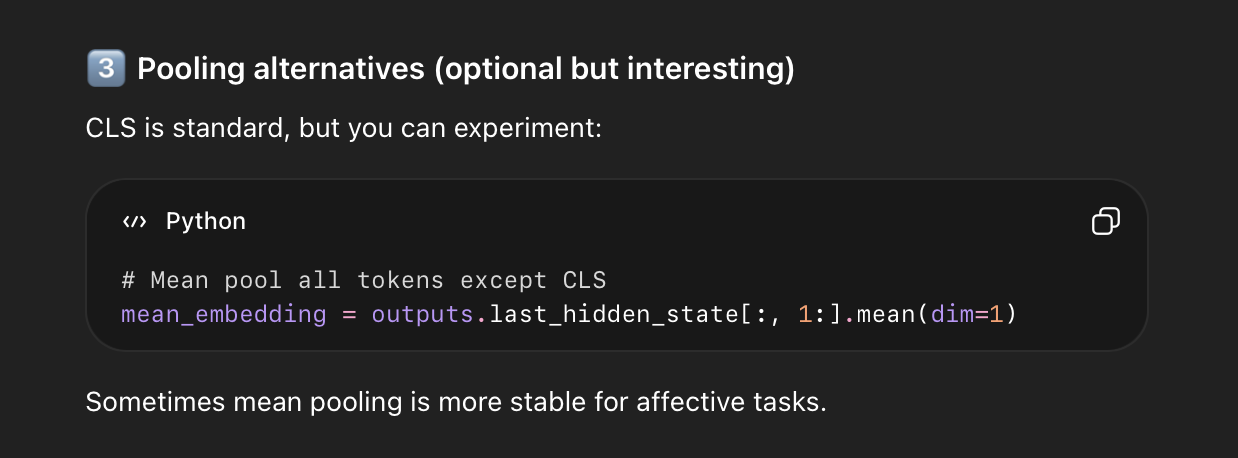

In [84]:
full_data = {}

for video_id, data in tqdm(audio_labels.items(), desc="Processing videos"):
    snippet_id = video_id

    try:
        embedding = extract_embedding(f"dataset_snippets/{snippet_id}.mp4")

        full_data[snippet_id] = {
            "embedding": embedding.tolist(),
            "emotion": data["emotion"],
            "probs": data["probs"],
            "cat_proba": data["cat_proba"]
        }
    except Exception as e:
        print(f"Error processing {video_id}: {e}")

Processing videos:   5%|▍         | 108/2358 [01:10<20:38,  1.82it/s][h264 @ 0x17c885df0] mmco: unref short failure
[h264 @ 0x17c885df0] mmco: unref short failure
[h264 @ 0x17c885df0] mmco: unref short failure
[h264 @ 0x17c885df0] mmco: unref short failure
[h264 @ 0x17c885df0] mmco: unref short failure
[h264 @ 0x17c885df0] mmco: unref short failure
Processing videos:  11%|█         | 264/2358 [02:55<15:51,  2.20it/s][h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
[h264 @ 0x17c878590] mmco: unref short failure
Processing videos:  14%|█▎        | 319/2358 [03:19<20:21,  1.67it/s][h264 @ 0x32f799a90] mmco: unref short fa

In [85]:
import json

with open("full_data.json", "w") as f:
    json.dump(full_data, f)

In [87]:
full_data["17yo Oscar playing with Ipad2 Mouse application specifically for cats_snip_0"].keys()

dict_keys(['embedding', 'emotion', 'probs', 'cat_proba'])

## Now training MLP

In [88]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict
import random

In [95]:
class SnippetDataset(Dataset):
    """Dataset for snippet embeddings with weighted KL loss."""

    def __init__(self, snippet_ids, metadata_list, data_dict):
        # Build a fast lookup: snippet_id -> metadata
        meta_lookup = {m["snippet_id"]: m for m in metadata_list}

        self.samples = []
        for sid in snippet_ids:
            entry   = data_dict[sid]
            meta    = meta_lookup[sid]
            embedding  = torch.tensor(entry["embedding"],  dtype=torch.float32)
            probs      = torch.tensor(entry["probs"],      dtype=torch.float32)
            cat_proba  = torch.tensor(meta["cat_proba"],   dtype=torch.float32)
            self.samples.append((embedding, probs, cat_proba))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [96]:
def video_split(metadata_list, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Split snippet IDs so that all snippets from the same original_video
    land in the same partition (group split).
    """
    # Group snippets by video
    video_to_snippets = defaultdict(list)
    for m in metadata_list:
        video_to_snippets[m["original_video"]].append(m["snippet_id"])

    videos = list(video_to_snippets.keys())
    random.seed(seed)
    random.shuffle(videos)

    n          = len(videos)
    n_test     = max(1, int(n * test_ratio))
    n_val      = max(1, int(n * val_ratio))

    test_videos  = videos[:n_test]
    val_videos   = videos[n_test:n_test + n_val]
    train_videos = videos[n_test + n_val:]

    def collect(vids):
        ids = []
        for v in vids:
            ids.extend(video_to_snippets[v])
        return ids

    return collect(train_videos), collect(val_videos), collect(test_videos)

In [188]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=(256, 128), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.net(x)
        # return torch.log_softmax(logits, dim=-1)   # log-probs for KLDivLoss
        return logits

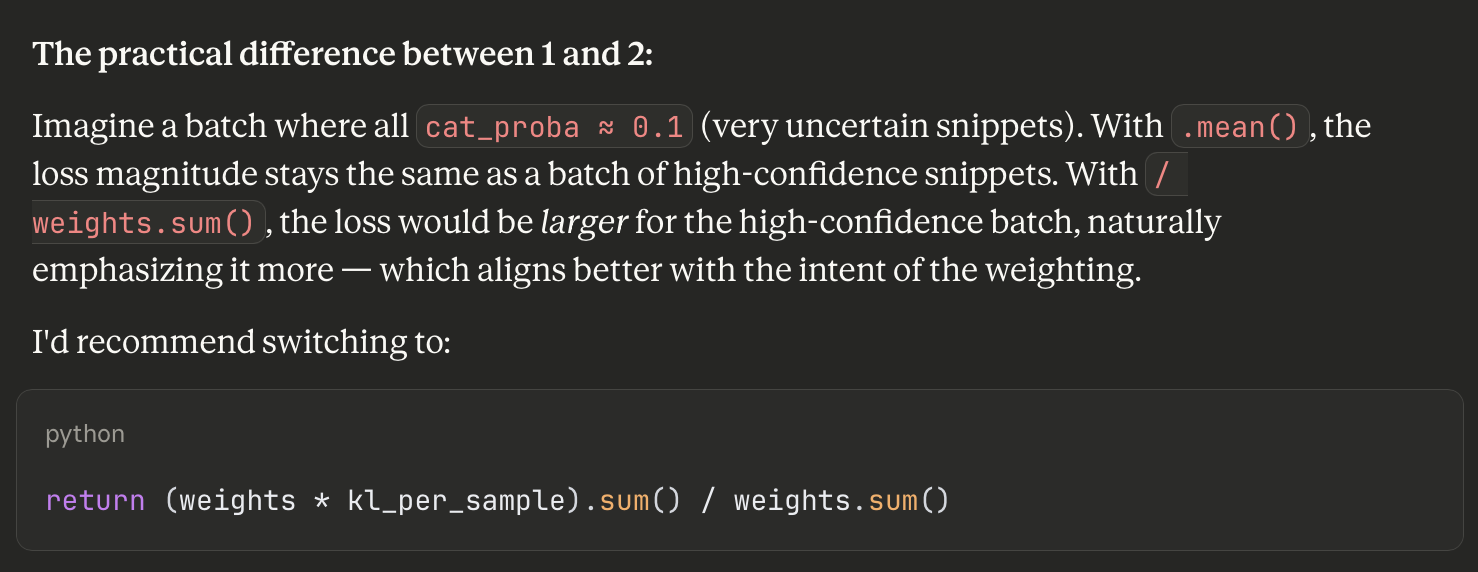

In [189]:
def weighted_kl_loss(log_pred, target_probs, cat_proba):
    """
    KL(target || pred) per sample, weighted by cat_proba^2.
    PyTorch's KLDivLoss expects (log_input, target).
    """
    # Per-sample KL: sum over classes
    kl_per_sample = torch.sum(
        target_probs * (torch.log(target_probs.clamp(min=1e-9)) - log_pred),
        dim=-1
    )                                    # shape: (B,)
    weights = cat_proba ** 2            # shape: (B,)
    return (weights * kl_per_sample).sum() / weights.sum()

In [190]:
from sklearn.metrics import f1_score
from sklearn.metrics import f1_score, confusion_matrix
import torch.nn.functional as F

In [191]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

In [207]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            ce = at * ce
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

In [204]:
def run_epoch(model, loader, optimizer, criterion, device, train=True, return_preds=False):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for embeddings, probs, cat_proba in loader:
            # embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
            embeddings = embeddings.float().to(device)
            
            probs      = probs.to(device)
            cat_proba  = cat_proba.to(device)

            log_pred = model(embeddings)
            # loss     = weighted_kl_loss(log_pred, probs, cat_proba)
            logits = model(embeddings)
            hard_labels = probs.argmax(dim=-1)
            loss = criterion(logits, hard_labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(embeddings)
            n          += len(embeddings)

            # Accumulate hard labels for F1
            preds   = log_pred.argmax(dim=-1).cpu().numpy()
            targets = probs.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets)

    avg_loss = total_loss / n
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    if return_preds:
        return avg_loss, f1, np.array(all_targets), np.array(all_preds)
    else:
        return avg_loss, f1

In [205]:
from torch.utils.data import WeightedRandomSampler

In [195]:
from collections import Counter

In [216]:
def train(
    metadata_list,          # list of metadata dicts
    data_dict,              # dict keyed by snippet_id
    # ── model hyper-params ──
    hidden_dims=(256, 128),
    dropout=0.3,
    # ── training hyper-params ──
    epochs=50,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    patience=7,             # early stopping patience
    # ── split ratios ──
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42,
    device=None,
    gamma=2.0               # focal loss gamma
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    f1_scores = []
    losses = []

    # ── split ──
    train_ids, val_ids, test_ids = video_split(
        metadata_list, val_ratio=val_ratio, test_ratio=test_ratio, seed=seed
    )
    print(f"Split  →  train: {len(train_ids)}  val: {len(val_ids)}  test: {len(test_ids)}")

    # ── datasets & loaders ──
    train_ds = SnippetDataset(train_ids, metadata_list, data_dict)
    val_ds   = SnippetDataset(val_ids,   metadata_list, data_dict)
    test_ds  = SnippetDataset(test_ids,  metadata_list, data_dict)

    # ── infer dims from first sample ──
    sample_emb, sample_probs, _ = train_ds[0]
    input_dim  = sample_emb.shape[0]
    output_dim = sample_probs.shape[0]
    print(f"input_dim={input_dim}  output_dim={output_dim}")

    # compute sample weights
    train_labels = [train_ds[i][1].argmax().item() for i in range(len(train_ds))]
    class_counts = np.array([Counter(train_labels).get(i, 0) for i in range(output_dim)])
    sample_weights = 1.0 / class_counts[train_labels]
    sample_weights = torch.tensor(sample_weights, dtype=torch.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)

    all_labels = [probs.argmax().item() for _, probs, _ in test_loader.dataset]
    print(Counter(all_labels))

    # ── model ──
    model = MLP(input_dim, output_dim, hidden_dims=hidden_dims, dropout=dropout).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    counts = np.array([Counter(train_ds[i][1].argmax().item() for i in range(len(train_ds))).get(i,0) for i in range(output_dim)])
    weights = 1.0 / (counts + 1e-6)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(alpha=weights, gamma=gamma)

    # ── training ──
    best_val_loss  = float("inf")
    best_state     = None
    epochs_no_imp  = 0

    val_targets_all, val_preds_all = None, None
    test_targets_all, test_preds_all = None, None

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = run_epoch(
            model, 
            train_loader, 
            optimizer, 
            criterion, 
            device, 
            train=True
        )
        val_loss, val_f1, val_targets, val_preds = run_epoch(
            model, 
            val_loader, 
            optimizer, 
            criterion, 
            device, 
            train=False, 
            return_preds=True
        )
        scheduler.step(val_loss)

        f1_scores.append((train_f1, val_f1))
        losses.append((train_loss, val_loss))

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs}\n\ttrain loss: {train_loss:.5f} | train f1: {train_f1:.5f}\n\tval loss: {val_loss:.5f} | val f1: {val_f1:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= patience:
                print(f"Early stopping triggered after {epoch} epochs.")
                break

    # ── test evaluation ──
    model.load_state_dict(best_state)
    model.to(device)
    test_loss, test_f1, test_targets_all, test_preds_all = run_epoch(
        model, test_loader, optimizer, criterion, device, train=False, return_preds=True
    )

    # confusion matrix for test set
    cm = confusion_matrix(test_targets_all, test_preds_all)

    print(f"\nBest val loss : {best_val_loss:.5f}")
    print(f"Test loss     : {test_loss:.5f} | Test f1: {test_f1:.5f}")
    print(f"Test confusion matrix:\n{cm}")

    return model, f1_scores, losses, cm

In [223]:
np.random.seed(0)

model, f1_scores, losses, cm = train(
    metadata, 
    full_data, 

    test_ratio=0.2,
    val_ratio=0.1,

    epochs=21, 
    batch_size=16,
    dropout=0.3,            # safer
    hidden_dims=(512, 256, 128), # larger MLP

    patience=100,

    lr=5e-4,
    weight_decay=1e-4,

    device=DEVICE
)

Using device: mps
Split  →  train: 1704  val: 210  test: 444
input_dim=768  output_dim=10
Counter({4: 131, 5: 92, 8: 43, 0: 39, 7: 38, 2: 26, 9: 25, 6: 24, 1: 14, 3: 12})
Epoch   1/21
	train loss: 0.01579 | train f1: 0.16027
	val loss: 0.01073 | val f1: 0.01779
Epoch  10/21
	train loss: 0.00362 | train f1: 0.57650
	val loss: 0.01164 | val f1: 0.04864
Epoch  20/21
	train loss: 0.00221 | train f1: 0.66924
	val loss: 0.01148 | val f1: 0.07932

Best val loss : 0.01073
Test loss     : 0.01150 | Test f1: 0.04892
Test confusion matrix:
[[ 1 16  2  6  0  0  5  4  0  5]
 [ 0  5  2  3  0  0  3  0  0  1]
 [ 0  8  1  8  0  0  2  0  0  7]
 [ 0  5  1  2  0  0  3  0  0  1]
 [ 2 52 10 17  0  0 27  2  0 21]
 [ 1 26  5 23  0  0 15  7  0 15]
 [ 1  7  0  3  0  0  8  2  0  3]
 [ 3  8  0  9  0  0 13  0  0  5]
 [ 1 13  4  9  0  0  6  2  0  8]
 [ 1  6  1  4  0  0  5  0  0  8]]


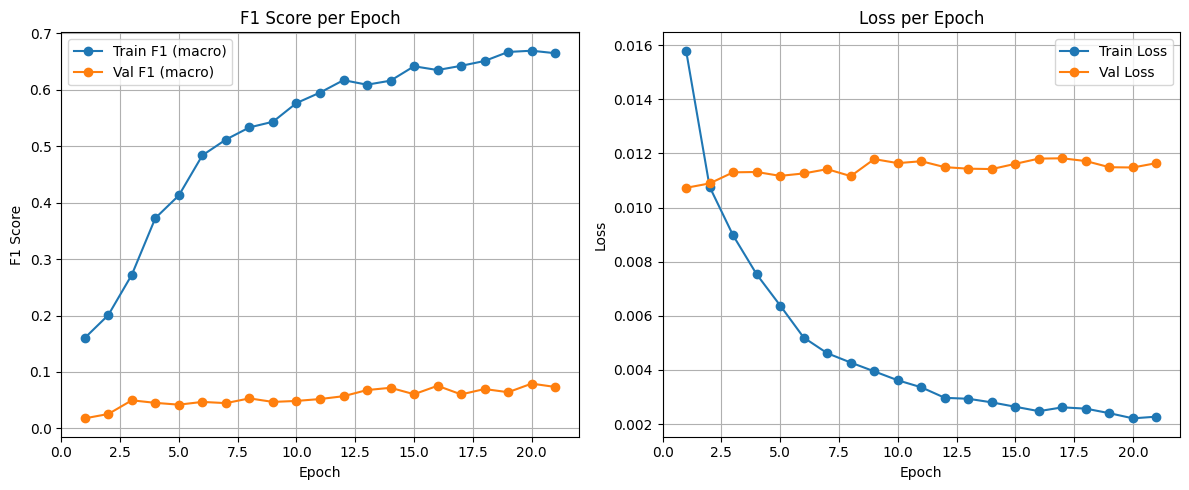

In [224]:
import matplotlib.pyplot as plt
import numpy as np

# Convert lists to arrays for easier plotting
train_f1 = [f[0] for f in f1_scores]
val_f1   = [f[1] for f in f1_scores]

train_loss = [l[0] for l in losses]
val_loss   = [l[1] for l in losses]

epochs = np.arange(1, len(f1_scores) + 1)

# ── Plot F1 scores ──
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_f1, label="Train F1 (macro)", marker='o')
plt.plot(epochs, val_f1, label="Val F1 (macro)", marker='o')
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score per Epoch")
plt.legend()
plt.grid(True)

# ── Plot Loss ──
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
plt.plot(epochs, val_loss, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

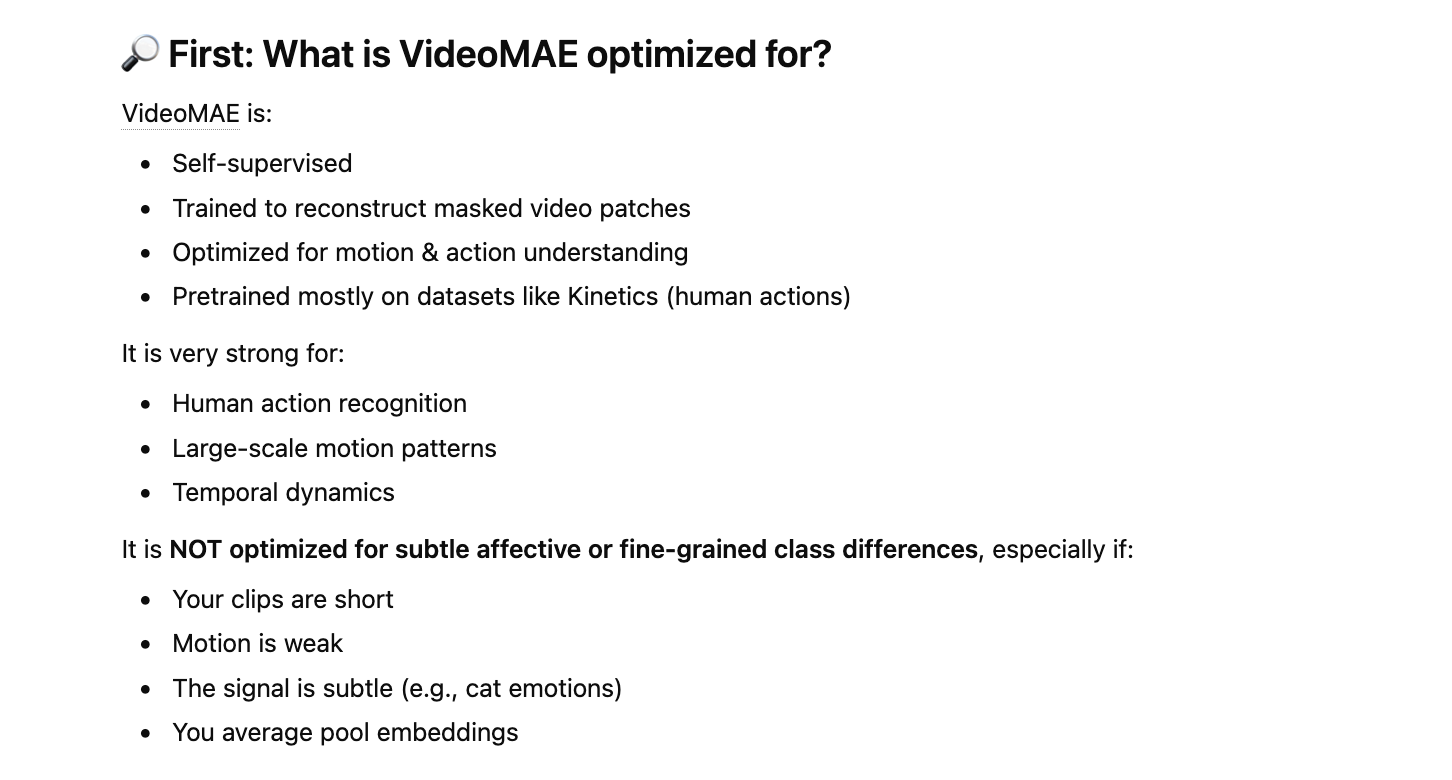

# VideoMAE failed, what next?

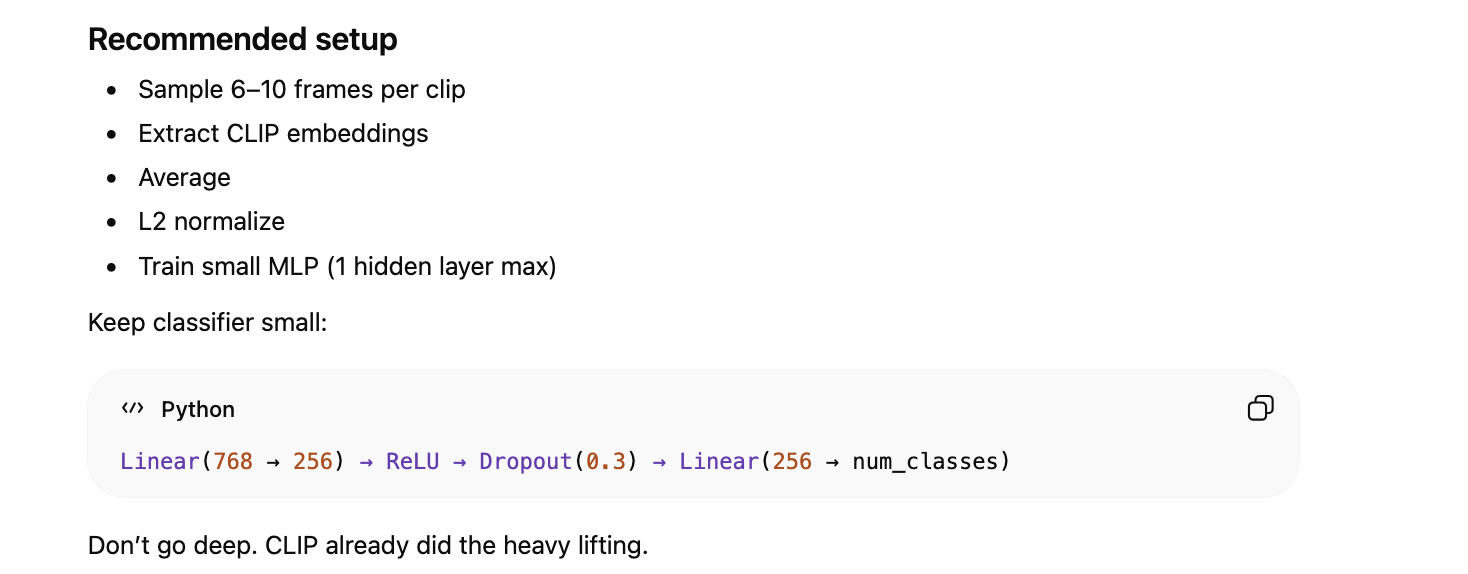

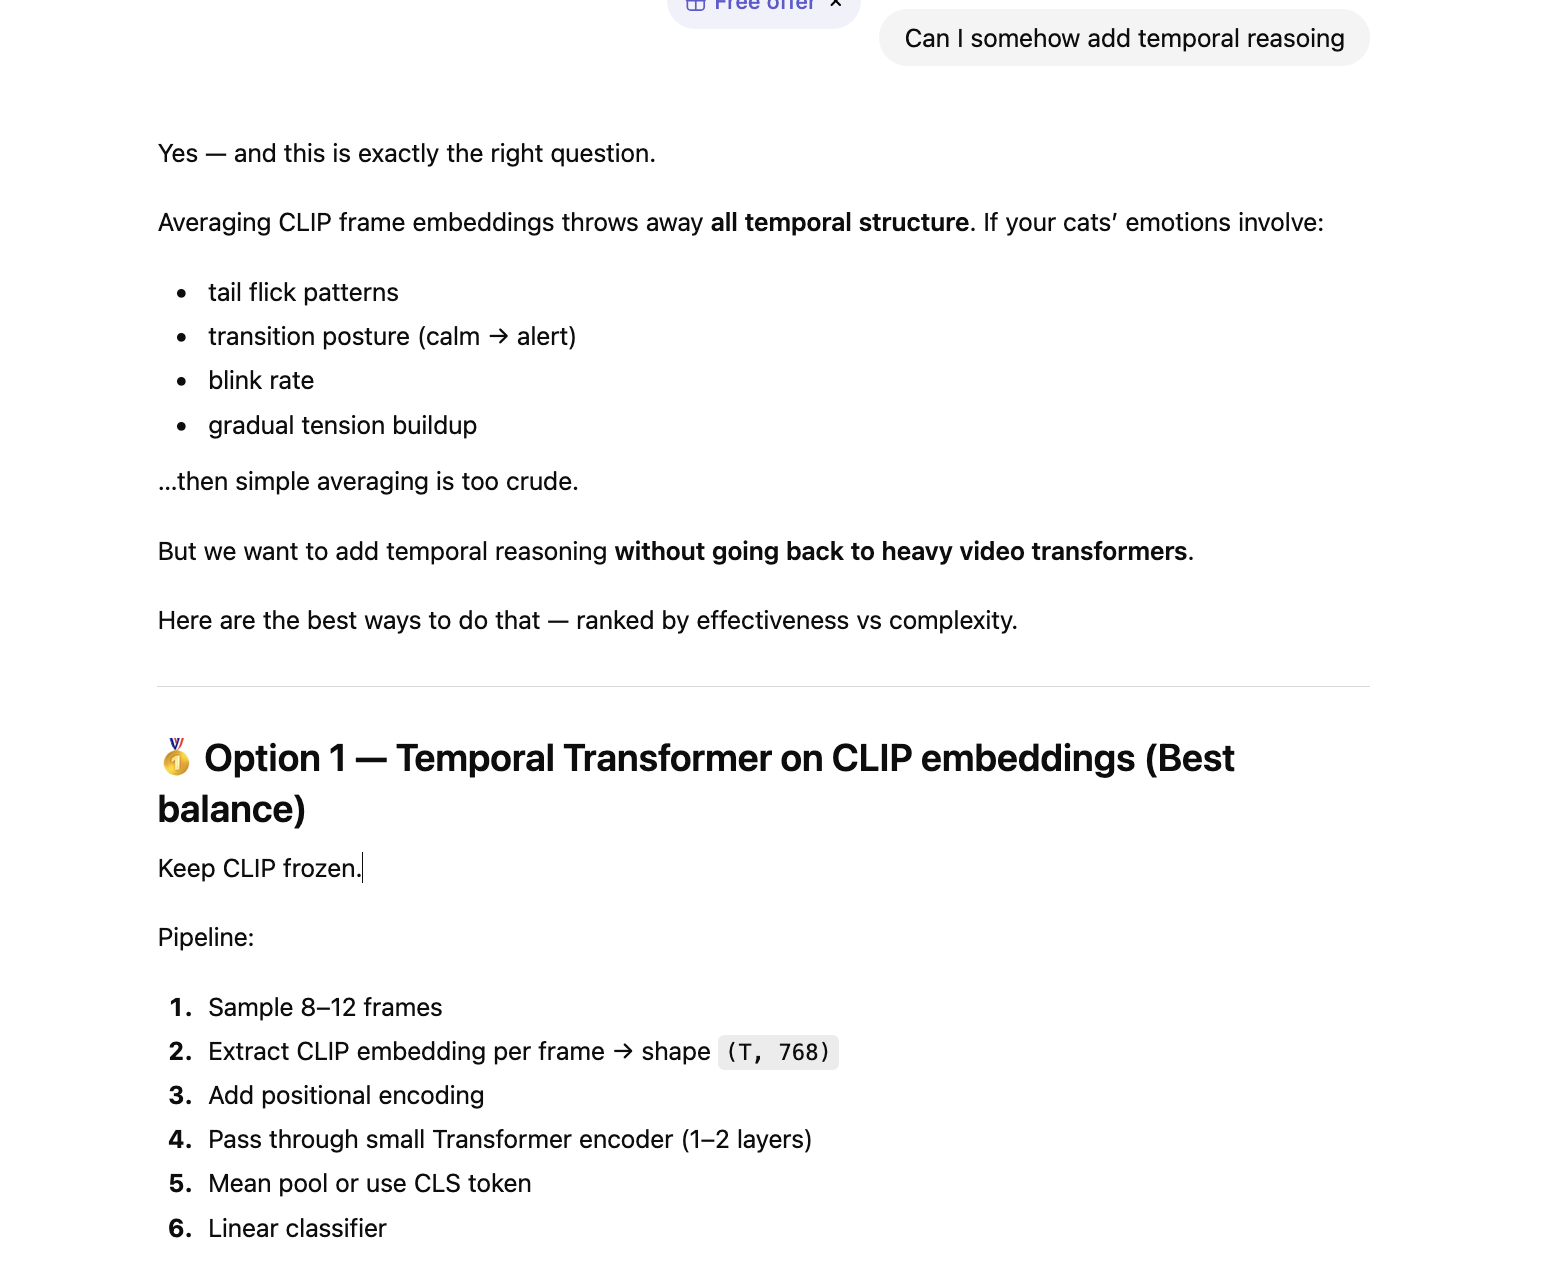

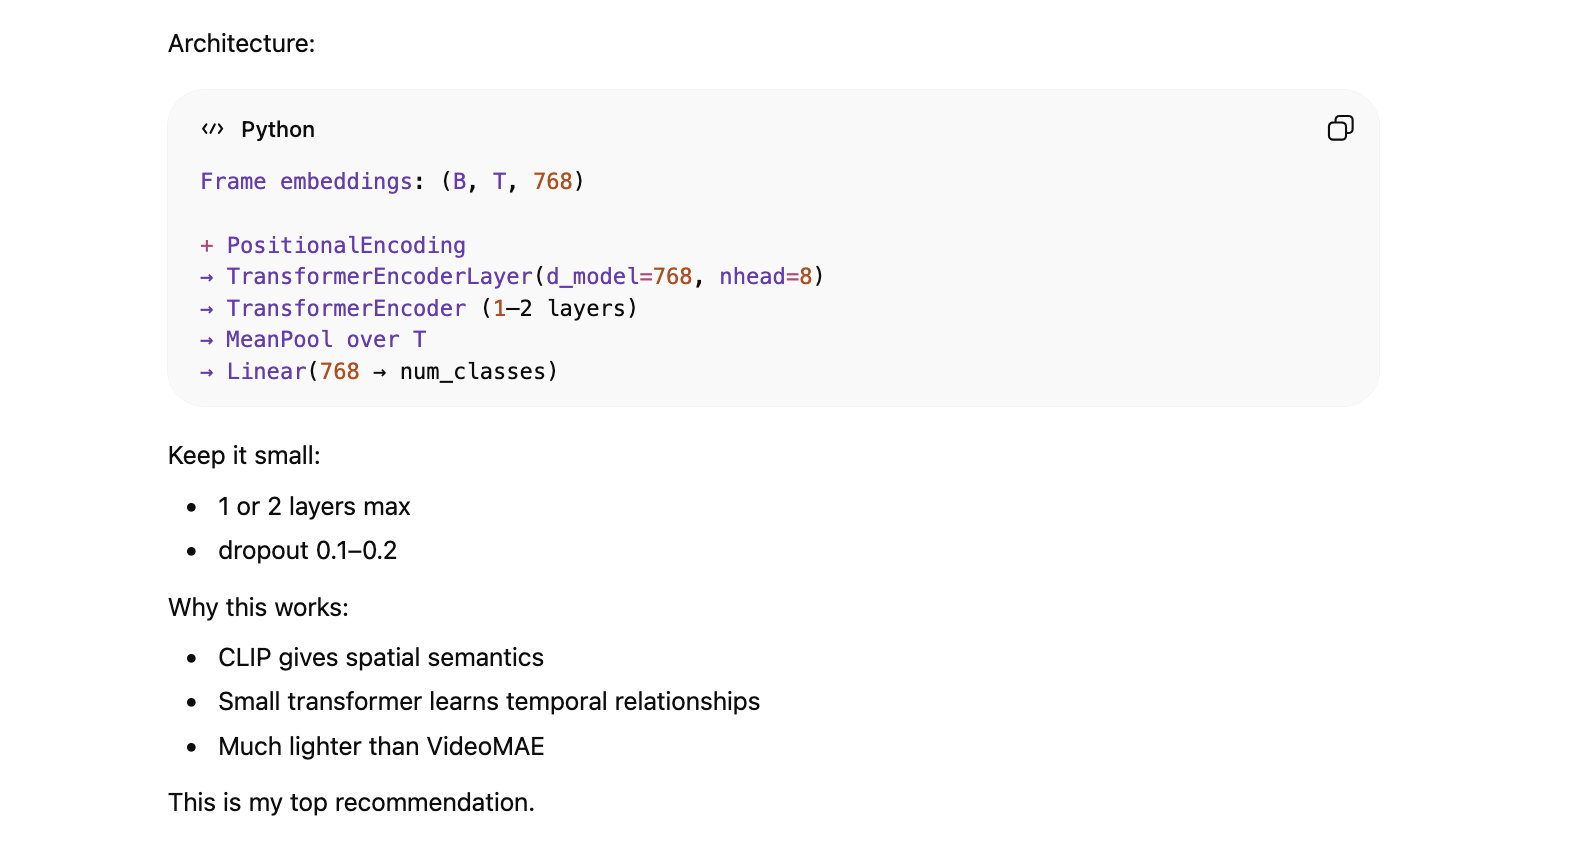

## CLIP without temporal transformer

Recommended setup

• Sample 6-10 frames per clip

• Extract CLIP embeddings

• Average

• L2 normalize

• Train small MLP (1 hidden layer max)

Keep classifier small:

‹> Python

Linear (768 → 256) → ReLU → Dropout (0.3) → Linear(256 → num_classes)
Don't go deep. CLIP already did the heavy lifting.

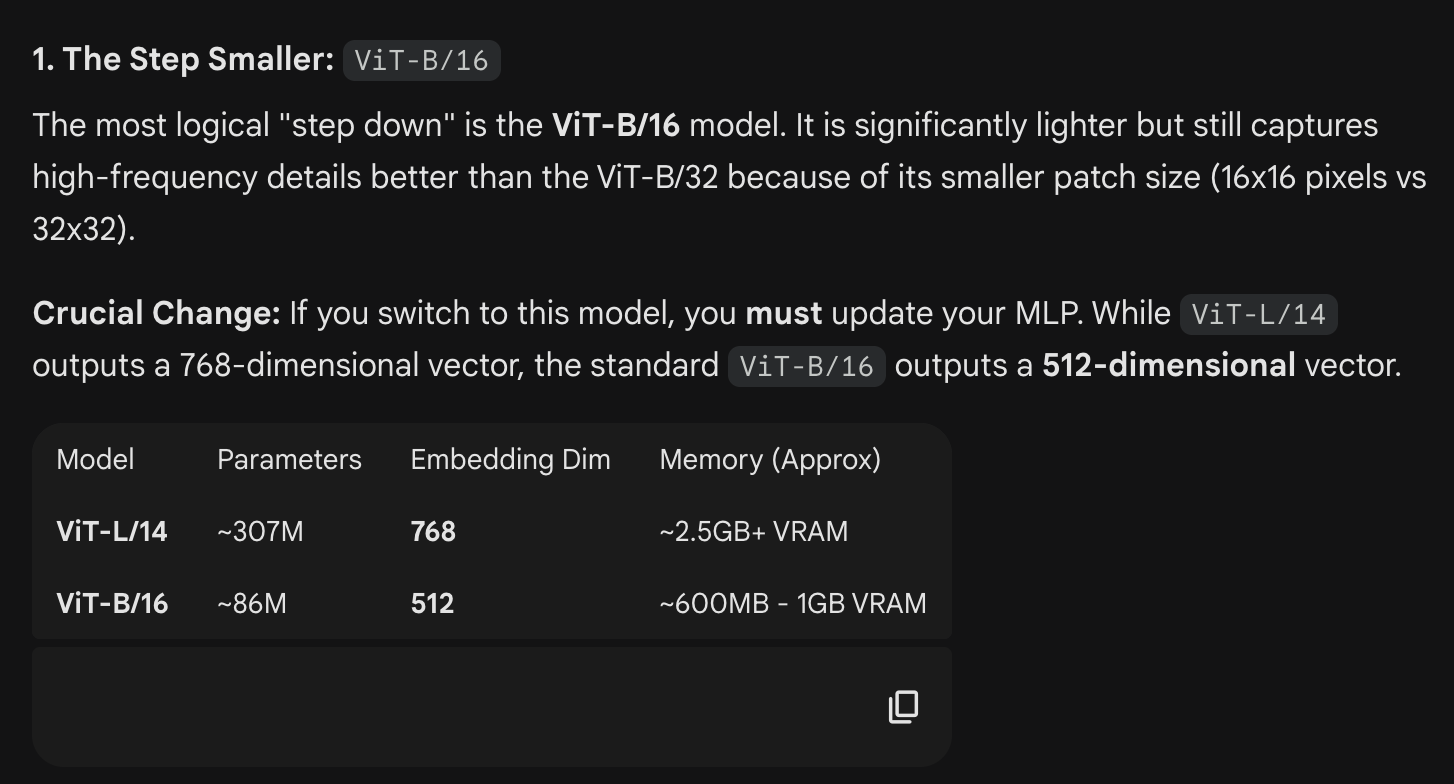

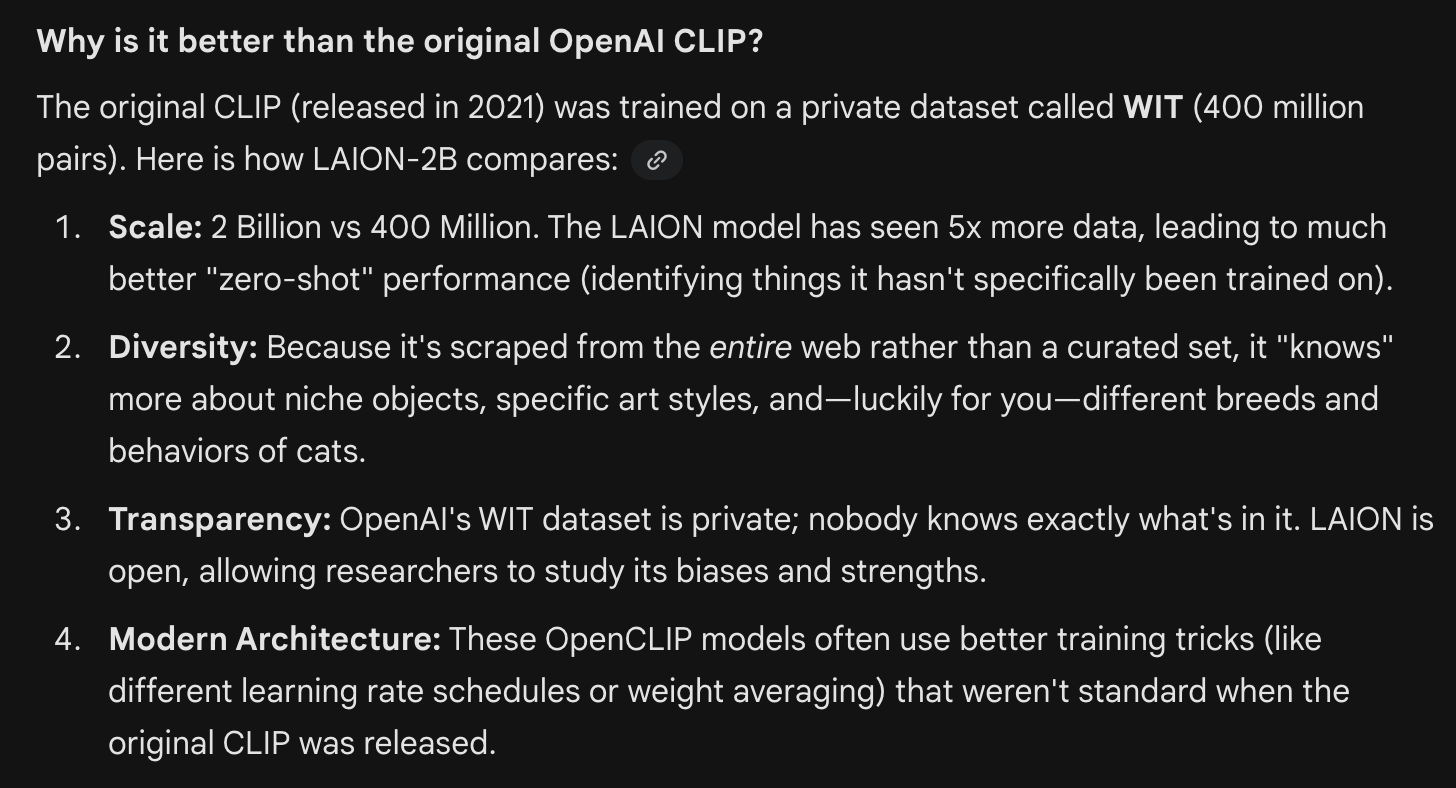

In [225]:
import torch
import open_clip

# Optimization for M2
device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

# Load ViT-B/16 (512-dim)
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16', 
    pretrained='laion2b_s32b_b82k'
)
model = model.to(device)
model.eval()

print(f"Model loaded on {device}. Embedding dimension: {model.visual.output_dim}")
# Output should be 512

ModuleNotFoundError: No module named 'open_clip'

!pip install open-clip-torch timm ftfy regex

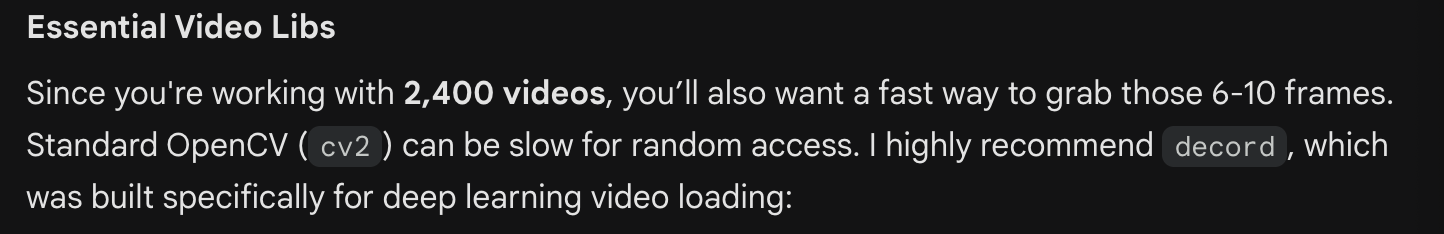

pip install decord

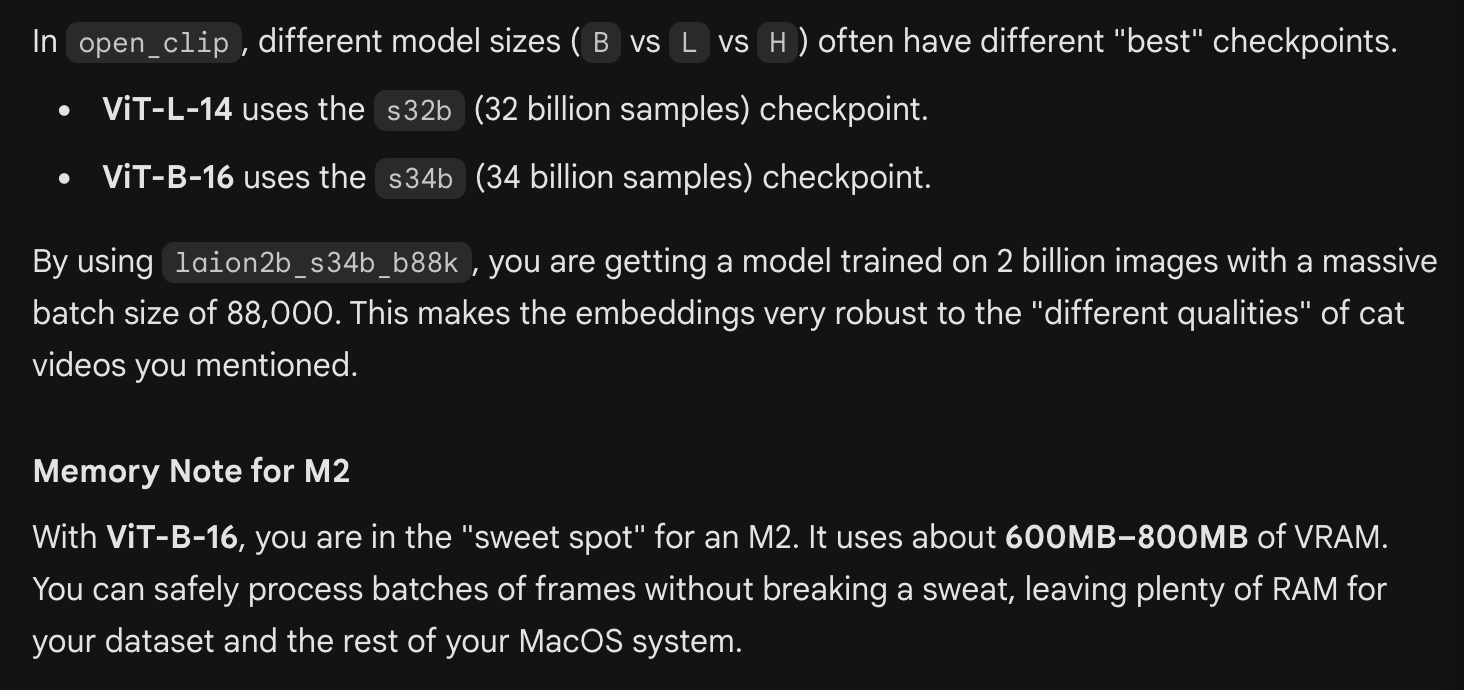

In [230]:
import torch
import open_clip

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

# Updated for ViT-B-16 with the correct LAION tag
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16', 
    pretrained='laion2b_s34b_b88k'
)
model = model.to(device)
model.eval()

print(f"Model loaded on {device}!")
print(f"Input resolution: {model.visual.image_size}")
print(f"Embedding dimension: {model.visual.output_dim}") # Should be 512

Model loaded on mps!
Input resolution: (224, 224)
Embedding dimension: 512


In [234]:
# sampling frames with temporal percentage positions
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def sample_frames_temporal(
    video_path: str,
    num_frames: int = 8,
    start_ratio: float = 0.0,
    end_ratio: float = 1.0
):
    """
    Samples frames using temporal percentage positions.
    
    Args:
        video_path: path to video file
        num_frames: number of frames to sample
        start_ratio: where sampling starts (0-1)
        end_ratio: where sampling ends (0-1)
        
    Returns:
        frames (list of np.ndarray in RGB)
    """
    
    video_path = str(video_path)
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        raise ValueError("Video has 0 frames.")
    
    # Generate evenly spaced temporal positions
    positions = np.linspace(start_ratio, end_ratio, num_frames)
    frame_indices = (positions * (total_frames - 1)).astype(int)
    
    frames = []
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if not ret:
            continue
        
        # Convert BGR → RGB for matplotlib / CLIP
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    
    cap.release()
    
    return frames

In [236]:
def show_sampled_frames(frames, title=None):
    """
    Displays sampled frames nicely in a row.
    """
    n = len(frames)
    
    plt.figure(figsize=(3 * n, 4))
    
    for i, frame in enumerate(frames):
        plt.subplot(1, n, i + 1)
        plt.imshow(frame)
        plt.axis("off")
        plt.title(f"Frame {i+1}")
    
    if title:
        plt.suptitle(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

Random video path: dataset_snippets/我が家のお猫様 トイレを覚える_snip_1.mp4


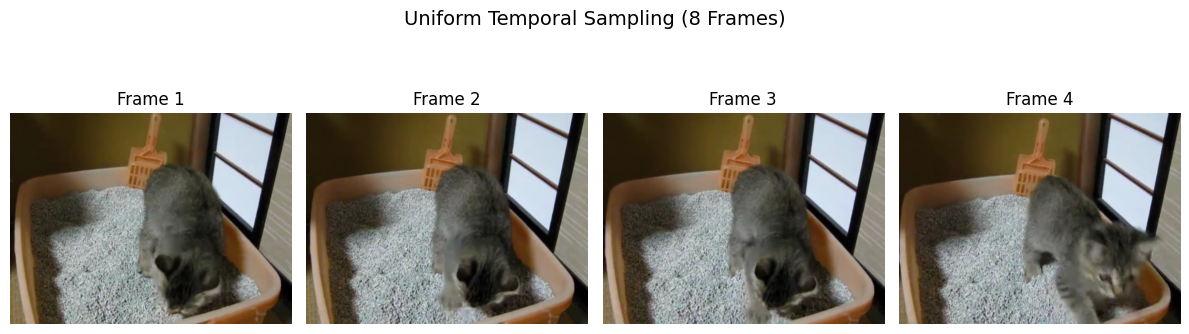

In [242]:
random_video_path = f"dataset_snippets/我が家のお猫様 トイレを覚える_snip_1.mp4"
print(f"Random video path: {random_video_path}")

frames = sample_frames_temporal(random_video_path, num_frames=8)

show_sampled_frames(frames, title="Uniform Temporal Sampling (8 Frames)")